In [1]:
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from rasterio.enums import Resampling
from numpy.lib.stride_tricks import sliding_window_view
import config
# Setup Paths (Adjust DATA_DIR to your local environment)
DATA_DIR = Path("./data") # Update this
STATES_SHP = config.STATES_SHP
COUNTIES_SHP = config.COUNTIES_SHP
RADIANCE_OLDER = config.RADIANCE_OLDER
RADIANCE_NEWER = config.RADIANCE_NEWER
IMPERV_OLDER = config.IMPERV_OLDER
IMPERV_NEWER = config.IMPERV_NEWER

from geocube.api.core import make_geocube
test_states = ["North Carolina"]
window_size = 3

In [2]:
def plot_nc_urban_core(
    raster_da, 
    counties_shp_path, 
    title="Radiance Plot", 
    vmin=None, 
    vmax=None, 
    cmap='magma',
    buffer_deg=0.05,
    outline_color='white'
):
    """
    Clips and plots a raster focused on the Wake/Durham/Orange/Chatham urban core.
    Includes a fix to filter for NC counties only (avoiding Orange County, CA).
    """
    
    # 1. Setup Counties Vector
    counties = gpd.read_file(counties_shp_path)
    
    # FILTER FIX: We must specify State FIPS '37' (NC) to avoid grabbing 
    # Orange County, CA or Chatham County, GA.
    target_names = ['Wake', 'Durham', 'Orange', 'Chatham']
    
    roi_gdf = counties[
        (counties['NAME'].isin(target_names)) & 
        (counties['STATEFP'] == '37') # <--- CRITICAL FIX
    ]
    
    if roi_gdf.empty:
        raise ValueError("Could not find specified NC counties. Check STATEFP or names.")
        
    # Ensure CRS matches the raster
    if roi_gdf.crs != raster_da.rio.crs:
        roi_gdf = roi_gdf.to_crs(raster_da.rio.crs)

    # 2. Define Clip Extent
    minx, miny, maxx, maxy = roi_gdf.total_bounds
    
    # Add buffer
    minx -= buffer_deg
    miny -= buffer_deg
    maxx += buffer_deg
    maxy += buffer_deg
    
    # 3. Clip the Raster (Now calculates bounds only for NC counties)
    try:
        clipped_da = raster_da.rio.clip_box(minx, miny, maxx, maxy)
    except Exception:
        # Fallback if raster doesn't fully cover the area (e.g. edge cases)
        print("Warning: Clip extent might be outside raster bounds.")
        clipped_da = raster_da

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
    
    # Plot Raster
    clipped_da.plot(
        ax=ax, 
        cmap=cmap, 
        vmin=vmin, 
        vmax=vmax, 
        add_colorbar=True,
        cbar_kwargs={'label': 'Radiance (nW/cm²/sr)', 'shrink': 0.8}
    )
    
    # Plot County Outlines
    roi_gdf.boundary.plot(
        ax=ax, 
        edgecolor=outline_color, 
        linewidth=1.5, 
        alpha=0.8
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_axis_off() 
    
    plt.tight_layout()
    plt.show()

In [3]:
# =========================================================
# 2. LOAD & PREPARE MASTER GRID (VIIRS)
# =========================================================
print("Loading VIIRS (Master Grid)...")

viirs_da = rioxarray.open_rasterio(RADIANCE_OLDER).squeeze()

# Handle nodata strictly
if viirs_da.rio.nodata is not None:
    viirs_da = viirs_da.where(viirs_da != viirs_da.rio.nodata)

# =========================================================
# 3. DEFINE TEST EXTENT (NC + VA)
# =========================================================
print(f"Defining Test Extent {test_states}...")

full_states_gdf = gpd.read_file(STATES_SHP)
subset_gdf = full_states_gdf[full_states_gdf['NAME'].isin(test_states)]

if subset_gdf.empty:
    raise ValueError("Could not find test states! Check 'NAME' spelling.")

# Match CRS and Get Bounds
subset_gdf = subset_gdf.to_crs(viirs_da.rio.crs)
minx, miny, maxx, maxy = subset_gdf.total_bounds

# Clip Master Grid (Compute immediately)
viirs_da = viirs_da.rio.clip_box(minx, miny, maxx, maxy)
viirs_da.load() # <--- Forces the clip to happen NOW in memory

print(f"Test Extent Set. Master Grid shape: {viirs_da.shape}")

# =========================================================
# 4. RASTERIZE STATE SHAPES (Strict Masking)
# =========================================================
print("Rasterizing State Boundaries...")

# Create a master mask so we only train/predict inside state borders (no ocean/out-of-bounds)
subset_gdf['STATEFP'] = subset_gdf['STATEFP'].astype(int)

state_id_da = make_geocube(
    vector_data=subset_gdf,
    measurements=["STATEFP"],
    like=viirs_da, 
    fill=0         
).STATEFP

# Ensure the state_id matches the target bounds and coordinates exactly
master_state_mask = (state_id_da > 0)

# =========================================================
# 5. LOAD & RESAMPLE IMPERVIOUS DATA
# =========================================================
print("Loading and Resampling Impervious Data...")

def load_and_match(path, target_da):
    """Eager load, clip, and resample"""
    da = rioxarray.open_rasterio(path).squeeze()
    
    # Clip First (Crucial optimization)
    minx, miny, maxx, maxy = target_da.rio.bounds()
    da_clipped = da.rio.clip_box(minx, miny, maxx, maxy, crs=target_da.rio.crs)
    
    # Handle Nodata
    if da.rio.nodata is not None:
        da_clipped = da_clipped.where(da_clipped != da.rio.nodata)

    # Reproject Match (Runs in memory immediately)
    matched = da_clipped.rio.reproject_match(
        target_da,
        resampling=Resampling.average
    )
    return matched

imp_old_da = load_and_match(IMPERV_OLDER, viirs_da)
imp_new_da = load_and_match(IMPERV_NEWER, viirs_da)

Loading VIIRS (Master Grid)...
Defining Test Extent ['North Carolina']...
Test Extent Set. Master Grid shape: (681, 2142)
Rasterizing State Boundaries...
Loading and Resampling Impervious Data...


In [4]:
# =========================================================
# 6. VECTORIZE SPATIAL NEIGHBORHOODS
# =========================================================
print("Converting 2D rasters into Machine Learning features...")

def create_spatial_features(data_array, window=5):
    """ Converts a 2D map into a 1D array of 5x5 spatial windows. """
    pad_size = window // 2
    # Fill NaNs with 0 for edge padding
    filled_data = np.nan_to_num(data_array.values, 0)
    padded_data = np.pad(filled_data, pad_width=pad_size, mode='reflect')
    
    windows = sliding_window_view(padded_data, window_shape=(window, window))
    H, W = data_array.shape
    return windows.reshape(H * W, window * window)

# Create 2D array masks to ensure we only train on valid data inside the state
valid_data_mask_2d = master_state_mask.values & ~np.isnan(viirs_da.values) & ~np.isnan(imp_old_da.values)
valid_mask_1d = valid_data_mask_2d.flatten()

# Extract training features (2019)
X_old_full = create_spatial_features(imp_old_da, window_size)
y_old_full = viirs_da.values.flatten()

# Subset to valid pixels only
X_train = X_old_full[valid_mask_1d]
y_train = y_old_full[valid_mask_1d]

print(f"Training dataset ready: {X_train.shape[0]} valid pixels, {X_train.shape[1]} features.")

Converting 2D rasters into Machine Learning features...
Training dataset ready: 797075 valid pixels, 9 features.


In [5]:
# =========================================================
# 7. TRAIN RANDOM FOREST
# =========================================================
print("Training Spatial Random Forest (This may take a moment)...")
import lightgbm as lgb
# Replaces your RandomForestRegressor line
model = lgb.LGBMRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# =========================================================
# 8. PREDICT & GRANDFATHER (RESIDUAL BLEND)
# =========================================================
print("Predicting 2021 Radiance...")
X_new_full = create_spatial_features(imp_new_da, window_size)

# Predict Baseline (2019) and Future (2021)
pred_old_1d = model.predict(X_old_full)
pred_new_1d = model.predict(X_new_full)

# Calculate Spatial Residuals (Actual 2019 - Predicted 2019)
residuals_1d = y_old_full - pred_old_1d

# Apply Residuals to the new prediction
final_pred_1d = pred_new_1d + residuals_1d

# Reconstruct 2D Map (Pure NumPy array)
predicted_radiance_2021_array = final_pred_1d.reshape(viirs_da.shape)

# =========================================================
# 9. EXPLICIT MASKING (Bypassing Xarray Alignment Issues)
# =========================================================
print("Applying explicit change mask to perfectly grandfather static areas...")

# 1. Create the mask logic using pure NumPy values to prevent coordinate mismatches
change_mask_vals = (imp_new_da.values > imp_old_da.values + 0.5)

# 2. Blend the arrays using np.where (Condition, True, False)
blended_vals = np.where(
    change_mask_vals, 
    predicted_radiance_2021_array, 
    viirs_da.values
)

# 3. Re-apply the master state mask (set out-of-bounds to NaN)
final_vals = np.where(
    master_state_mask.values, 
    blended_vals, 
    np.nan
)

# 4. Package the final blended array safely back into Xarray
final_blended_da = xr.DataArray(
    final_vals,
    coords=viirs_da.coords,
    dims=viirs_da.dims
)

# Assign proper geospatial metadata
final_blended_da.rio.write_crs(viirs_da.rio.crs, inplace=True)
final_blended_da.rio.write_nodata(np.nan, inplace=True)

print("Simulation Complete!")

Training Spatial Random Forest (This may take a moment)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.085651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 797075, number of used features: 9
[LightGBM] [Info] Start training from score 1.787771
Predicting 2021 Radiance...


/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/tworm/Documents/nightlights/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Applying explicit change mask to perfectly grandfather static areas...
Simulation Complete!


Loading Observed 2021 Radiance for comparison...


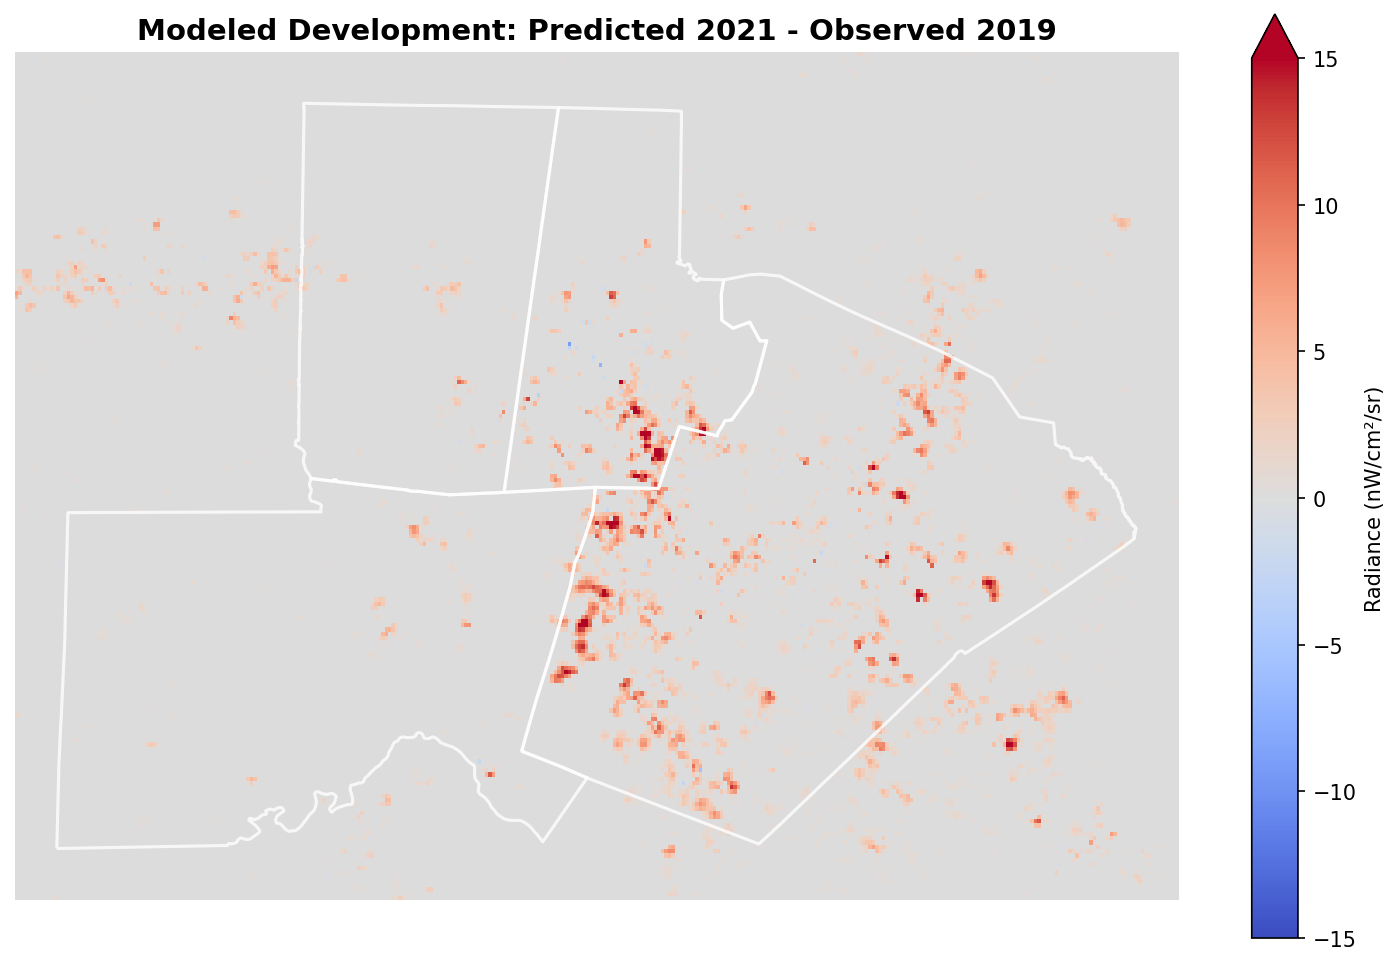

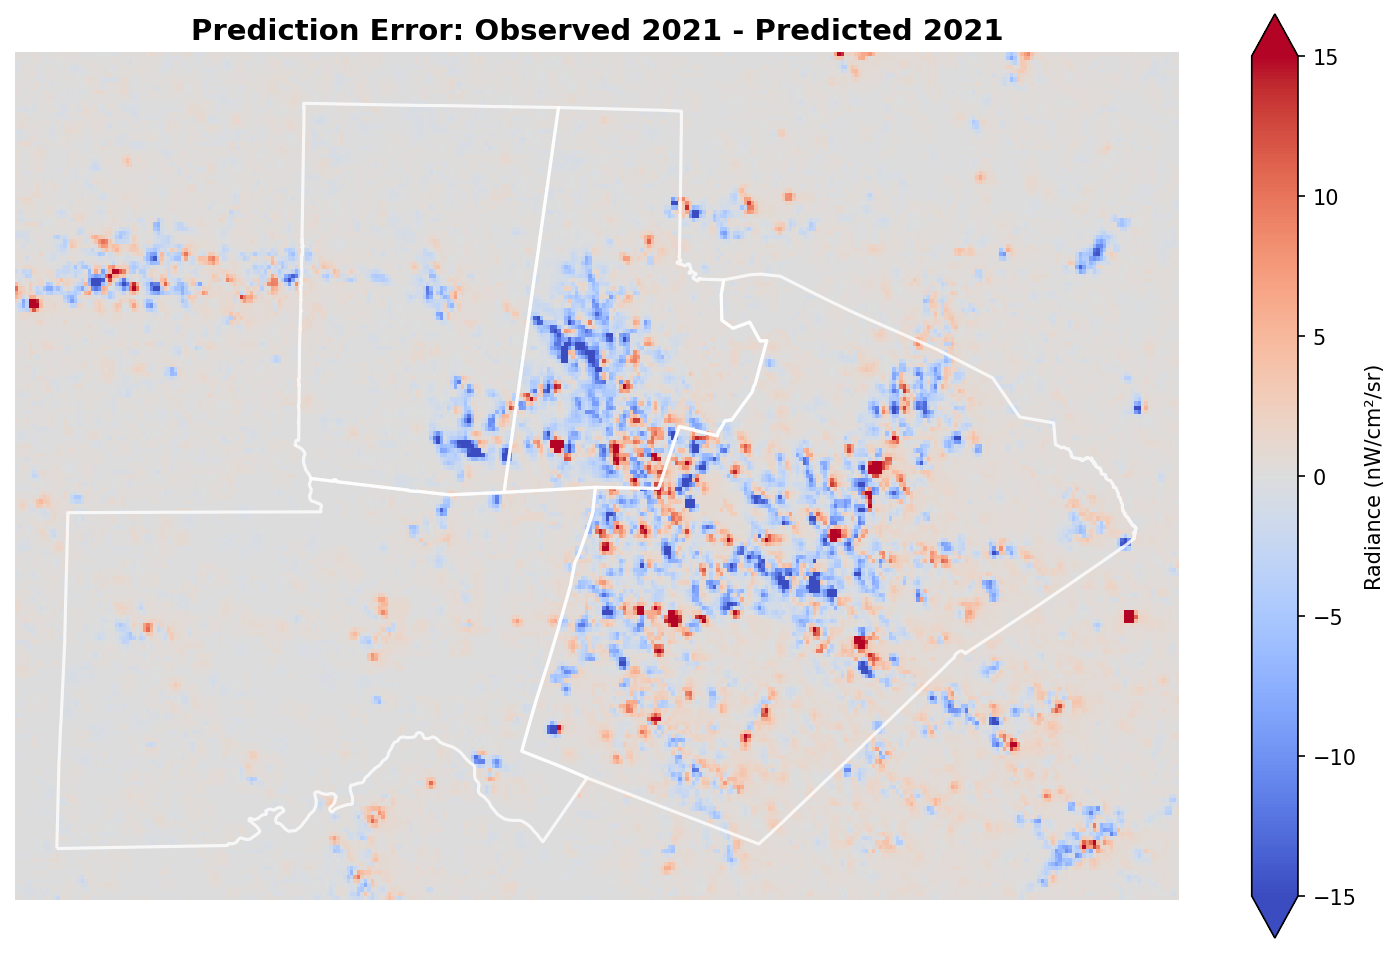

In [6]:
# =========================================================
# 11. VISUALIZE DIFFERENCES (CHANGE & ERROR MAPS)
# =========================================================
print("Loading Observed 2021 Radiance for comparison...")

# Load and strictly clip the 2021 observed data just like we did for 2019
viirs_new_da = rioxarray.open_rasterio(config.RADIANCE_NEWER).squeeze()
viirs_new_da = viirs_new_da.rio.clip_box(minx, miny, maxx, maxy)

if viirs_new_da.rio.nodata is not None:
    viirs_new_da = viirs_new_da.where(viirs_new_da != viirs_new_da.rio.nodata)

# ---------------------------------------------------------
# Map 1: Expected Change (Predicted 2021 - Observed 2019)
# Positive (Red) = Model predicts it got brighter
# Negative (Blue) = Model predicts it got dimmer
# ---------------------------------------------------------
predicted_change_da = final_blended_da - viirs_da

plot_nc_urban_core(
    predicted_change_da, 
    COUNTIES_SHP, # Adjust if needed
    title="Modeled Development: Predicted 2021 - Observed 2019", 
    cmap='coolwarm', 
    vmin=-15,  # Symmetrical bounds are critical for diverging colormaps
    vmax=15
)

# ---------------------------------------------------------
# Map 2: Prediction Error (Observed 2021 - Predicted 2021)
# Positive (Red) = Reality was BRIGHTER than the model expected
# Negative (Blue) = Reality was DIMMER than the model expected
# ---------------------------------------------------------
prediction_error_da = viirs_new_da - final_blended_da

plot_nc_urban_core(
    prediction_error_da, 
    COUNTIES_SHP, # Adjust if needed
    title="Prediction Error: Observed 2021 - Predicted 2021", 
    cmap='coolwarm', 
    vmin=-15, 
    vmax=15
)

In [7]:
import numpy as np

# 1. Total Observed Radiance (The Baseline "Energy")
# Summing all valid pixels to get a Total Sum of Lights (SOL) index
total_observed_sol = float(viirs_new_da.sum().values)

# 2. Net Mismatch (Bias)
# Do the reds and blues cancel out, or does the model run generally hot/cold?
net_error = float(prediction_error_da.sum().values)
net_error_pct = (net_error / total_observed_sol) * 100

# 3. Total Absolute Mismatch (Total misplaced light)
# Converts all errors to positive to see the total volume of "wrong" predictions
absolute_error_da = np.abs(prediction_error_da)
total_abs_error = float(absolute_error_da.sum().values)
abs_error_pct = (total_abs_error / total_observed_sol) * 100

# 4. Mean Absolute Error (MAE) per pixel
mae = float(absolute_error_da.mean().values)

print("=== Regional Energy Mismatch Report ===")
print(f"Total Observed Sum of Lights: {total_observed_sol:,.2f} nW/cm²/sr")
print("---------------------------------------")
print(f"Net Mismatch (Bias):          {net_error:,.2f} nW/cm²/sr ({net_error_pct:+.2f}%)")
print(f"Total Absolute Mismatch:      {total_abs_error:,.2f} nW/cm²/sr ({abs_error_pct:.2f}%)")
print(f"Mean Absolute Error (MAE):    {mae:.3f} nW/cm²/sr per pixel")

=== Regional Energy Mismatch Report ===
Total Observed Sum of Lights: 2,668,948.00 nW/cm²/sr
---------------------------------------
Net Mismatch (Bias):          5,045.20 nW/cm²/sr (+0.19%)
Total Absolute Mismatch:      373,917.73 nW/cm²/sr (14.01%)
Mean Absolute Error (MAE):    0.469 nW/cm²/sr per pixel


In [8]:
# =========================================================
# NULL MODEL (Persistence Baseline) EVALUATION
# =========================================================
# The "prediction" of the null model is just the 2019 observed data
null_prediction_error_da = viirs_new_da - viirs_da

# 1. Net Mismatch (Bias) of the Null Model
# This tells us the actual regional growth/dimming between 2019 and 2021
null_net_error = float(null_prediction_error_da.sum().values)
null_net_error_pct = (null_net_error / total_observed_sol) * 100

# 2. Total Absolute Mismatch of the Null Model
null_absolute_error_da = np.abs(null_prediction_error_da)
null_total_abs_error = float(null_absolute_error_da.sum().values)
null_abs_error_pct = (null_total_abs_error / total_observed_sol) * 100

# 3. Mean Absolute Error (MAE) of the Null Model
null_mae = float(null_absolute_error_da.mean().values)

print("=== NULL MODEL (2019 Baseline) Mismatch Report ===")
print(f"Net Mismatch (Bias):          {null_net_error:,.2f} nW/cm²/sr ({null_net_error_pct:+.2f}%)")
print(f"Total Absolute Mismatch:      {null_total_abs_error:,.2f} nW/cm²/sr ({null_abs_error_pct:.2f}%)")
print(f"Mean Absolute Error (MAE):    {null_mae:.3f} nW/cm²/sr per pixel")
print("---------------------------------------")
print(f"Model Improvement over Null (MAE): {(null_mae - mae):.3f} nW/cm²/sr per pixel")

=== NULL MODEL (2019 Baseline) Mismatch Report ===
Net Mismatch (Bias):          104,216.41 nW/cm²/sr (+3.90%)
Total Absolute Mismatch:      658,139.31 nW/cm²/sr (24.66%)
Mean Absolute Error (MAE):    0.451 nW/cm²/sr per pixel
---------------------------------------
Model Improvement over Null (MAE): -0.017 nW/cm²/sr per pixel
